In [4]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')



# Import airpollution data
df_ap = pd.read_csv("data/train.csv")
df_ap.head(5)
df_ap.info()



,Place_ID X Date,Date,Place_ID,target,target_min,target_max,target_variance,target_count,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,...,L3_SO2_sensor_zenith_angle,L3_SO2_solar_azimuth_angle,L3_SO2_solar_zenith_angle,L3_CH4_CH4_column_volume_mixing_ratio_dry_air,L3_CH4_aerosol_height,L3_CH4_aerosol_optical_depth,L3_CH4_sensor_azimuth_angle,L3_CH4_sensor_zenith_angle,L3_CH4_solar_azimuth_angle,L3_CH4_solar_zenith_angle
0,010Q650 X 2020-01-02,2020-01-02,010Q650,38.0,23.0,53.0,769.50,92,11.000000,60.200001,...,38.593017,-61.752587,22.363665,1793.793579,3227.855469,0.010579,74.481049,37.501499,-62.142639,22.545118
1,010Q650 X 2020-01-03,2020-01-03,010Q650,39.0,25.0,63.0,1319.85,91,14.600000,48.799999,...,59.624912,-67.693509,28.614804,1789.960449,3384.226562,0.015104,75.630043,55.657486,-53.868134,19.293652
2,010Q650 X 2020-01-04,2020-01-04,010Q650,24.0,8.0,56.0,1181.96,96,16.400000,33.400002,...,49.839714,-78.342701,34.296977,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,010Q650 X 2020-01-05,2020-01-05,010Q650,49.0,10.0,55.0,1113.67,96,6.911948,21.300001,...,29.181258,-73.896588,30.545446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,010Q650 X 2020-01-06,2020-01-06,010Q650,21.0,9.0,52.0,1164.82,95,13.900001,44.700001,...,0.797294,-68.612480,26.899694,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df_ap.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30557 entries, 0 to 30556
Data columns (total 82 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Place_ID X Date                                      30557 non-null  object 
 1   Date                                                 30557 non-null  object 
 2   Place_ID                                             30557 non-null  object 
 3   target                                               30557 non-null  float64
 4   target_min                                           30557 non-null  float64
 5   target_max                                           30557 non-null  float64
 6   target_variance                                      30557 non-null  float64
 7   target_count                                         30557 non-null  int64  
 8   precipitable_water_entire_atmosphere                 30557 non-nul

In [6]:
df_ap.shape

(30557, 82)

In [9]:
# Checking for missing values
missing = pd.DataFrame(df_ap.isnull().sum(), columns=["Amount"])
missing['Percentage'] = round((missing['Amount']/df_ap.shape[0])*100, 2)
missing[missing['Amount'] != 0]

,Amount,Percentage
L3_NO2_NO2_column_number_density,2189,7.16
L3_NO2_NO2_slant_column_number_density,2189,7.16
L3_NO2_absorbing_aerosol_index,2189,7.16
L3_NO2_cloud_fraction,2189,7.16
L3_NO2_sensor_altitude,2189,7.16
...,...,...
L3_CH4_aerosol_optical_depth,24765,81.05
L3_CH4_sensor_azimuth_angle,24765,81.05
L3_CH4_sensor_zenith_angle,24765,81.05
L3_CH4_solar_azimuth_angle,24765,81.05


In [10]:
# Get columns where missing data is 80% or more
cols_high_missing = df_ap.columns[df_ap.isnull().mean() >= 0.8].tolist()
print(cols_high_missing)


['L3_CH4_CH4_column_volume_mixing_ratio_dry_air', 'L3_CH4_aerosol_height', 'L3_CH4_aerosol_optical_depth', 'L3_CH4_sensor_azimuth_angle', 'L3_CH4_sensor_zenith_angle', 'L3_CH4_solar_azimuth_angle', 'L3_CH4_solar_zenith_angle']


In [19]:
# Drop leakage columns
leakage_cols = ['target_min', 'target_max', 'target_variance', 'target_count']

# Drop columns with 80%+ missing
high_missing_cols = df_ap.columns[df_ap.isnull().mean() >= 0.8].tolist()


In [15]:
pd.Series(X.columns)

0                                     Date
1                                 Place_ID
2     precipitable_water_entire_atmosphere
3        relative_humidity_2m_above_ground
4        specific_humidity_2m_above_ground
                      ...                 
64                   L3_SO2_cloud_fraction
65             L3_SO2_sensor_azimuth_angle
66              L3_SO2_sensor_zenith_angle
67              L3_SO2_solar_azimuth_angle
68               L3_SO2_solar_zenith_angle
Length: 69, dtype: object

In [16]:
# convert date columns to date value
df_ap['Date'] = pd.to_datetime(df_ap['Date'])

df_ap['month']       = df_ap['Date'].dt.month
df_ap['day_of_week'] = df_ap['Date'].dt.dayofweek



In [18]:
df_ap.head()

,Place_ID X Date,Date,Place_ID,target,target_min,target_max,target_variance,target_count,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,...,L3_SO2_solar_zenith_angle,L3_CH4_CH4_column_volume_mixing_ratio_dry_air,L3_CH4_aerosol_height,L3_CH4_aerosol_optical_depth,L3_CH4_sensor_azimuth_angle,L3_CH4_sensor_zenith_angle,L3_CH4_solar_azimuth_angle,L3_CH4_solar_zenith_angle,month,day_of_week
0,010Q650 X 2020-01-02,2020-01-02,010Q650,38.0,23.0,53.0,769.50,92,11.000000,60.200001,...,22.363665,1793.793579,3227.855469,0.010579,74.481049,37.501499,-62.142639,22.545118,1,3
1,010Q650 X 2020-01-03,2020-01-03,010Q650,39.0,25.0,63.0,1319.85,91,14.600000,48.799999,...,28.614804,1789.960449,3384.226562,0.015104,75.630043,55.657486,-53.868134,19.293652,1,4
2,010Q650 X 2020-01-04,2020-01-04,010Q650,24.0,8.0,56.0,1181.96,96,16.400000,33.400002,...,34.296977,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,5
3,010Q650 X 2020-01-05,2020-01-05,010Q650,49.0,10.0,55.0,1113.67,96,6.911948,21.300001,...,30.545446,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,6
4,010Q650 X 2020-01-06,2020-01-06,010Q650,21.0,9.0,52.0,1164.82,95,13.900001,44.700001,...,26.899694,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0


In [17]:
# Get unique Place_IDs
places = df_ap['Place_ID'].unique()
print(f"Total unique places: {len(places)}")

# Split place IDs into train and validation sets
from sklearn.model_selection import train_test_split

places_train, places_val = train_test_split(places, test_size=0.2, random_state=42)

# Filter rows based on place membership
train_split = df_ap[df_ap['Place_ID'].isin(places_train)]
val_split   = df_ap[df_ap['Place_ID'].isin(places_val)]

print(f"Train rows: {len(train_split)}, Places: {len(places_train)}")
print(f"Val rows:   {len(val_split)},  Places: {len(places_val)}")


Total unique places: 340
Train rows: 24546, Places: 272
Val rows:   6011,  Places: 68


In [22]:
drop_cols = leakage_cols + high_missing_cols + ['Place_ID X Date', 'Date', 'Place_ID']

X_tr  = train_split.drop(columns=drop_cols + ['target'])
y_tr  = train_split['target']

X_val = val_split.drop(columns=drop_cols + ['target'])
y_val = val_split['target']


In [23]:
if 'X_tr' in globals():
    print('X_tr shape:', X_tr.shape)
else:
    print("X_tr is not defined (run the cell that creates X_tr, e.g. cell 10)")
print('X_val shape:', X_val.shape)
print('y_tr shape:', y_tr.shape)
print('y_val shape:', y_val.shape)

X_tr shape: (24546, 69)
X_val shape: (6011, 69)
y_tr shape: (24546,)
y_val shape: (6011,)


In [ ]:
#Cleaning the training data set first:
#check for mising values:

missing = X_tr.isnull().mean().sort_values(ascending=False)
print(missing[missing > 0])


L3_NO2_tropospheric_NO2_column_number_density          0.273201
L3_HCHO_cloud_fraction                                 0.236087
L3_HCHO_tropospheric_HCHO_column_number_density_amf    0.236087
L3_HCHO_tropospheric_HCHO_column_number_density        0.236087
L3_HCHO_solar_zenith_angle                             0.236087
                                                         ...   
L3_AER_AI_sensor_altitude                              0.006355
L3_AER_AI_sensor_azimuth_angle                         0.006355
L3_AER_AI_sensor_zenith_angle                          0.006355
L3_AER_AI_solar_azimuth_angle                          0.006355
L3_AER_AI_solar_zenith_angle                           0.006355
Length: 61, dtype: float64


In [ ]:
#check for data types
print(X_tr.dtypes.value_counts())

# Check if any non-numeric columns slipped through
print(X_tr.select_dtypes('object').columns.tolist())


float64    67
int32       2
Name: count, dtype: int64
[]


In [ ]:
#we look for outliers
X_tr.describe().T[['min', 'max', 'mean', 'std']]


,min,max,mean,std
precipitable_water_entire_atmosphere,0.420044,72.599998,15.168951,10.669450
relative_humidity_2m_above_ground,6.800000,100.000000,70.746188,18.764046
specific_humidity_2m_above_ground,0.000139,0.021615,0.006005,0.003808
temperature_2m_above_ground,-34.647879,37.437921,9.240207,9.451319
u_component_of_wind_10m_above_ground,-15.559646,17.955124,0.438870,2.710651
...,...,...,...,...
L3_SO2_sensor_zenith_angle,0.000000,66.111289,35.582395,18.937597
L3_SO2_solar_azimuth_angle,-179.880630,179.776125,-123.647736,71.894031
L3_SO2_solar_zenith_angle,0.000000,79.631711,46.543271,14.607455
month,1.000000,4.000000,2.094516,0.899350


In [27]:
#looking for duplicate rows in train data set
print(f"Duplicate rows: {X_tr.duplicated().sum()}")


Duplicate rows: 0


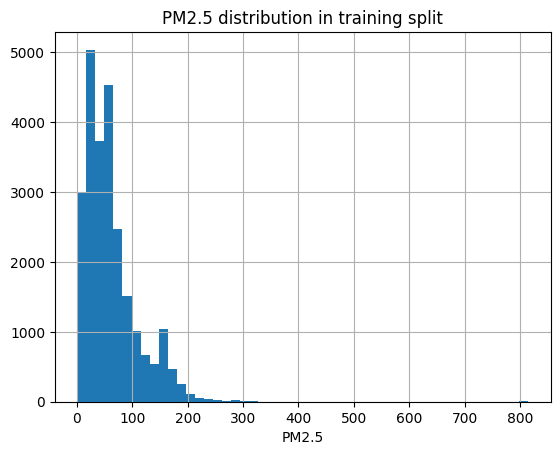

count    24546.000000
mean        62.030995
std         47.960782
min          1.000000
25%         26.000000
50%         51.000000
75%         80.000000
max        815.000000
Name: target, dtype: float64


In [ ]:
#Target distribution: checking for heavy skewed if so then log transform
import matplotlib.pyplot as plt

y_tr.hist(bins=50)
plt.title("PM2.5 distribution in training split")
plt.xlabel("PM2.5")
plt.show()

print(y_tr.describe())


In [29]:
#clean the training data only first :

imputer = SimpleImputer(strategy='median')
X_tr_imputed  = pd.DataFrame(imputer.fit_transform(X_tr),  columns=X_tr.columns)
X_val_imputed = pd.DataFrame(imputer.transform(X_val),     columns=X_tr.columns)


In [30]:
# Verify no missing values remain
print(X_tr_imputed.isnull().sum().sum())   # should be 0
print(X_val_imputed.isnull().sum().sum())  # should be 0

0
0


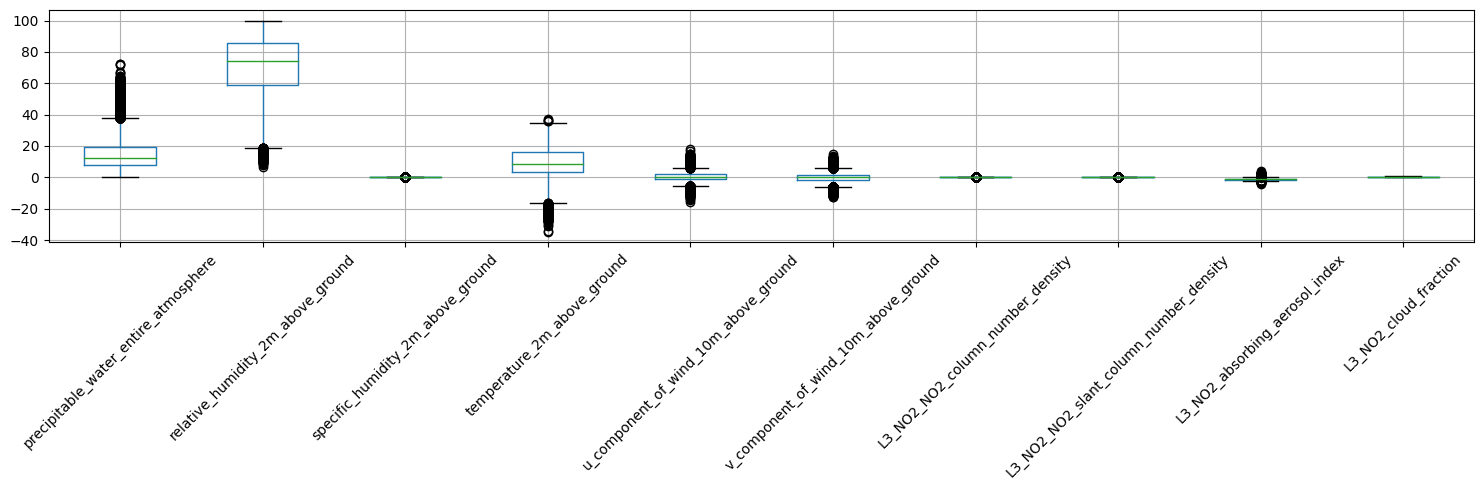

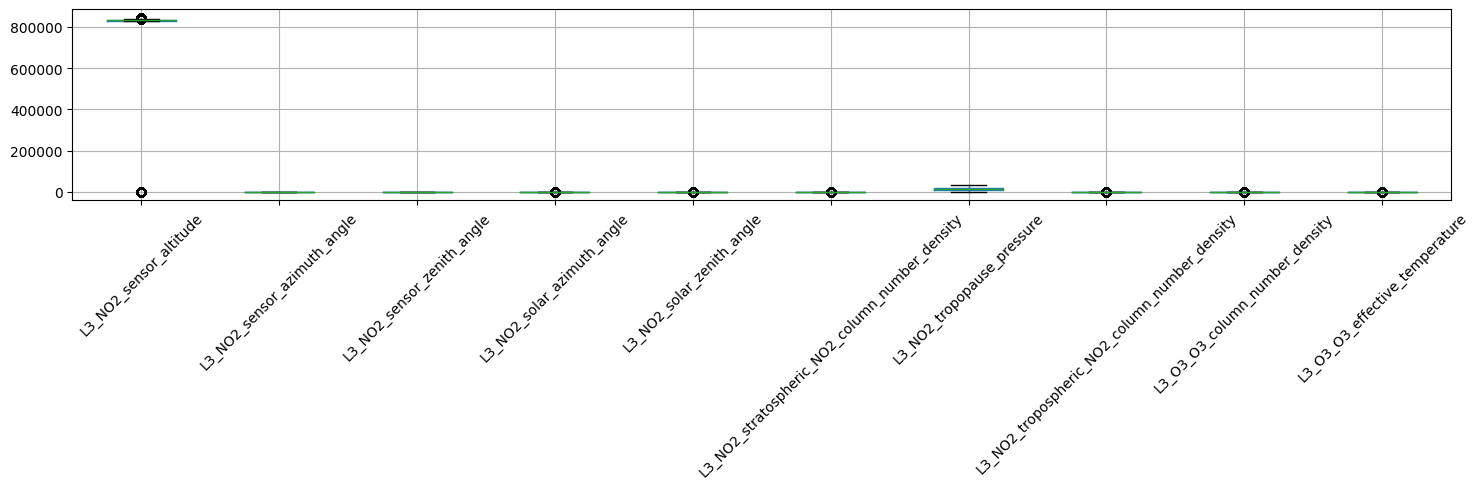

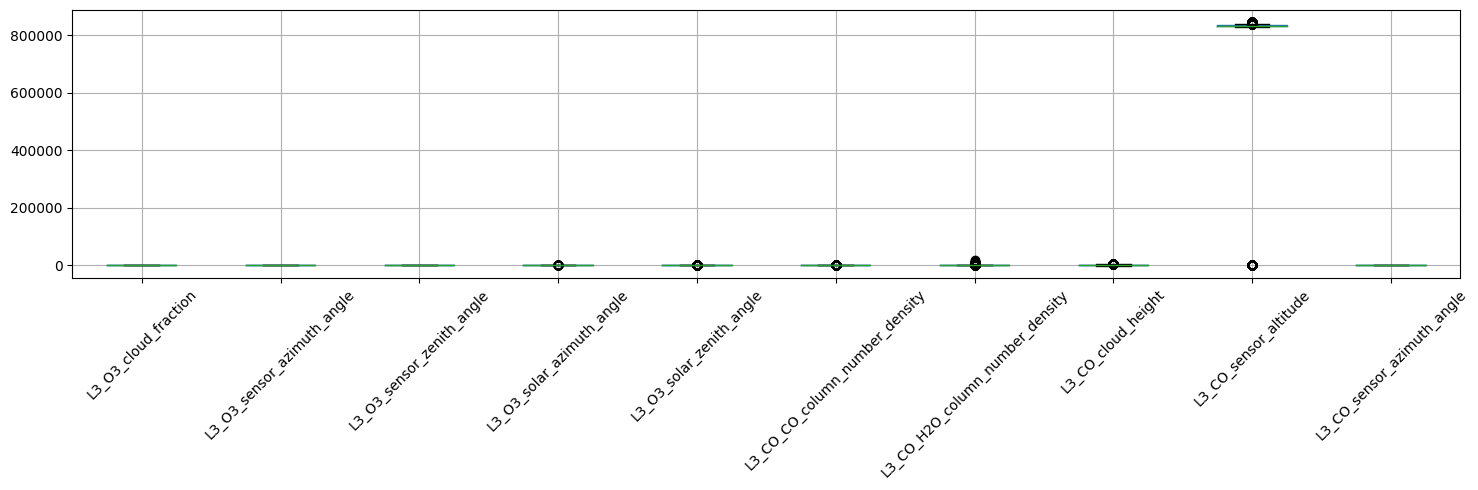

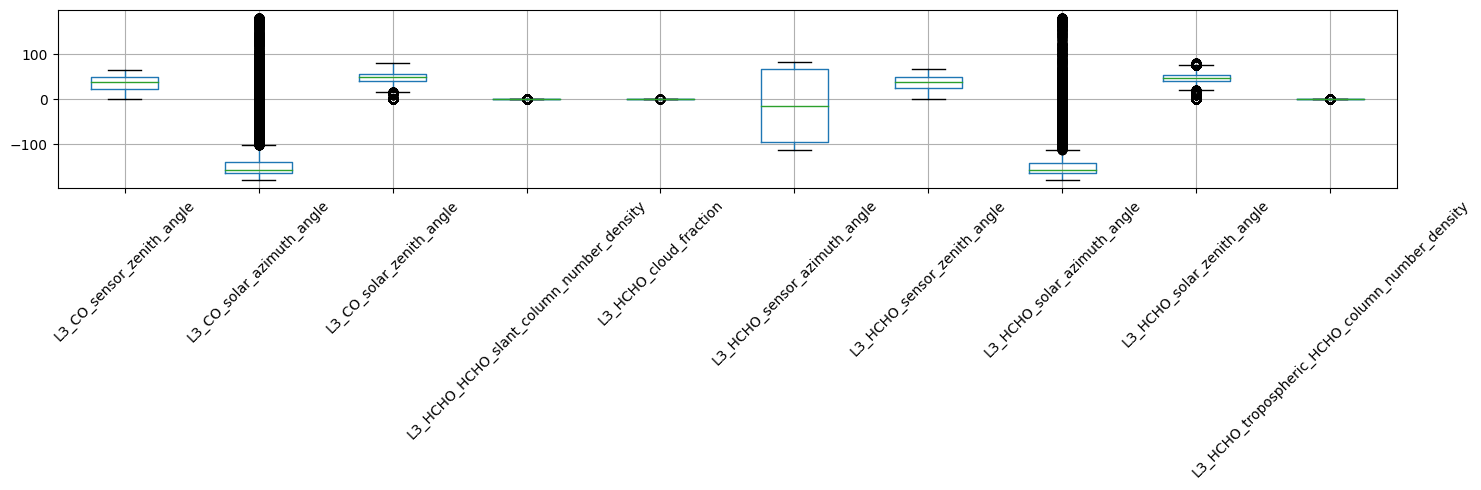

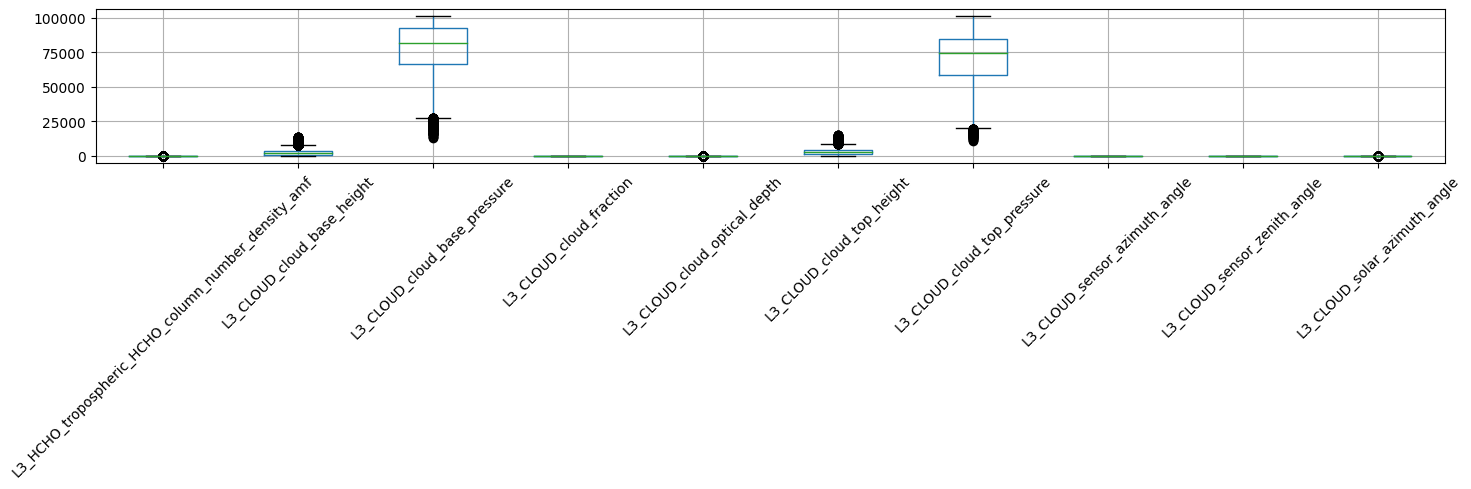

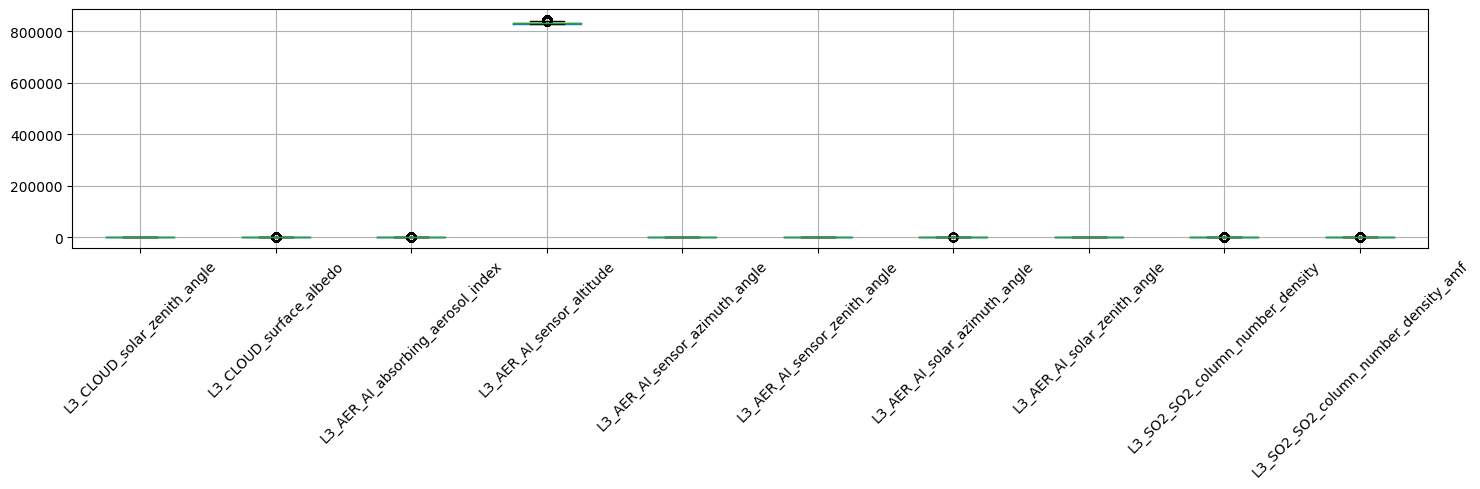

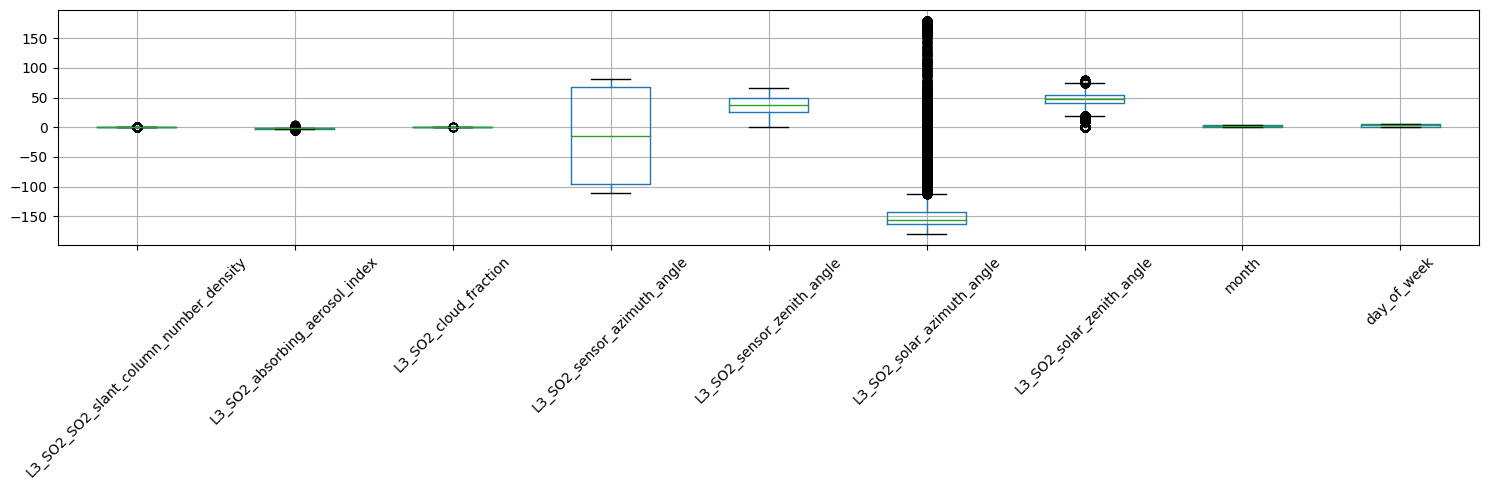

In [31]:
# Dealing  with outliers in the trainig data set 
import matplotlib.pyplot as plt

# Plot boxplots for all features in chunks of 10
cols = X_tr_imputed.columns.tolist()
chunk_size = 10

for i in range(0, len(cols), chunk_size):
    chunk = cols[i:i+chunk_size]
    X_tr_imputed[chunk].boxplot(figsize=(15, 5))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [32]:
#quantify the outliers in training data using IQR
Q1 = X_tr_imputed.quantile(0.25)
Q3 = X_tr_imputed.quantile(0.75)
IQR = Q3 - Q1

# Count outliers per column
outlier_counts = ((X_tr_imputed < (Q1 - 1.5 * IQR)) | 
                  (X_tr_imputed > (Q3 + 1.5 * IQR))).sum()

print(outlier_counts.sort_values(ascending=False))


L3_CO_solar_azimuth_angle                 4715
L3_HCHO_solar_azimuth_angle               4637
L3_SO2_solar_azimuth_angle                4581
L3_NO2_NO2_slant_column_number_density    3895
L3_SO2_SO2_column_number_density          3865
                                          ... 
L3_CO_sensor_zenith_angle                    0
L3_CLOUD_sensor_zenith_angle                 0
L3_CLOUD_sensor_azimuth_angle                0
L3_HCHO_sensor_azimuth_angle                 0
day_of_week                                  0
Length: 69, dtype: int64


In [33]:
#dealing with the outliers by clipping the IQR bounds
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

X_tr_clipped  = X_tr_imputed.clip(lower=lower, upper=upper, axis=1)

# Apply same bounds to validation (computed from train only!)
X_val_clipped = X_val_imputed.clip(lower=lower, upper=upper, axis=1)


In [34]:
#Verify results
# Recheck — outlier count should be 0 after clipping
outlier_counts_after = ((X_tr_clipped < (Q1 - 1.5 * IQR)) | 
                        (X_tr_clipped > (Q3 + 1.5 * IQR))).sum()
print(outlier_counts_after.sum())  # should be 0



0


In [ ]:
#Handle target skewness


In [3]:
coffee_quality.head()

,Unnamed: 0,quality_score,view_certificate_1,view_certificate_2,Cupping Protocol and Descriptors,View Green Analysis Details,Request a Sample,Species,Owner,Country of Origin,...,Moisture,Category One Defects,Quakers,Color,Category Two Defects,NA.3,Expiration,Certification Body,Certification Address,Certification Contact
0,0,83.75,NaN,NaN,NaN,NaN,NaN,Robusta,Ankole coffee producers coop,Uganda,...,12 %,0 full defects,0,Green,2 full defects,NaN,"June 26th, 2015",Uganda Coffee Development Authority,"Coffee House, Plot 35, Jinja Road, P.O. Box 72...",Clare Rwakatogoro - 256-41-256940/233073
1,0,83.50,NaN,NaN,NaN,NaN,NaN,Robusta,Nishant Gurjer,India,...,0 %,0 full defects,0,NaN,2 full defects,NaN,"October 31st, 2018",Specialty Coffee Association,"117 W 4th St, Suite 300 Santa Ana, CA 92701",Chris Buck - (562) 624-4100
2,0,83.25,NaN,NaN,NaN,NaN,NaN,Robusta,Andrew Hetzel,India,...,0 %,0 full defects,0,Green,0 full defects,NaN,"April 29th, 2016",Specialty Coffee Association,"117 W 4th St, Suite 300 Santa Ana, CA 92701",Chris Buck - (562) 624-4100
3,0,83.00,NaN,NaN,NaN,NaN,NaN,Robusta,UGACOF,Uganda,...,12 %,0 full defects,0,Green,7 full defects,NaN,"July 14th, 2015",Uganda Coffee Development Authority,"Coffee House, Plot 35, Jinja Road, P.O. Box 72...",Clare Rwakatogoro - 256-41-256940/233073
4,0,83.00,NaN,NaN,NaN,NaN,NaN,Robusta,Katuka Development Trust Ltd,Uganda,...,12 %,0 full defects,0,Green,3 full defects,NaN,"June 26th, 2015",Uganda Coffee Development Authority,"Coffee House, Plot 35, Jinja Road, P.O. Box 72...",Clare Rwakatogoro - 256-41-256940/233073


In [4]:
Y = coffee_quality["quality_score"]

# Data cleaning and feature engineering

In [5]:
coffee_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 44 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             28 non-null     int64  
 1   Species                28 non-null     object 
 2   Owner                  28 non-null     object 
 3   Country.of.Origin      28 non-null     object 
 4   Farm.Name              25 non-null     object 
 5   Lot.Number             6 non-null      object 
 6   Mill                   20 non-null     object 
 7   ICO.Number             17 non-null     object 
 8   Company                28 non-null     object 
 9   Altitude               25 non-null     object 
 10  Region                 26 non-null     object 
 11  Producer               26 non-null     object 
 12  Number.of.Bags         28 non-null     int64  
 13  Bag.Weight             28 non-null     object 
 14  In.Country.Partner     28 non-null     object 
 15  Harvest.

In [6]:
#for this exercise we will only deal with numeric variables

X = coffee_features.select_dtypes(['number'])

## Splitting data for testing 

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=42)

In [8]:
#dropping Quakers column and unnamed
#changing one of the altitude to log and droping the original
X_train["altitude_mean_log"] = np.log(X_train["altitude_mean_meters"])
X_train.drop(['altitude_mean_meters'], axis=1, inplace=True)
X_train.drop(['Quakers'], axis=1, inplace=True)
X_train.drop(['Unnamed: 0'], axis=1, inplace=True)

In [9]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 22 entries, 17 to 6
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Number.of.Bags        22 non-null     int64  
 1   Harvest.Year          22 non-null     int64  
 2   Fragrance...Aroma     22 non-null     float64
 3   Flavor                22 non-null     float64
 4   Aftertaste            22 non-null     float64
 5   Salt...Acid           22 non-null     float64
 6   Bitter...Sweet        22 non-null     float64
 7   Mouthfeel             22 non-null     float64
 8   Uniform.Cup           22 non-null     float64
 9   Clean.Cup             22 non-null     float64
 10  Balance               22 non-null     float64
 11  Cupper.Points         22 non-null     float64
 12  Total.Cup.Points      22 non-null     float64
 13  Moisture              22 non-null     float64
 14  Category.One.Defects  22 non-null     int64  
 15  Category.Two.Defects  22 

In [10]:
altitude_low_meters_mean = X_train["altitude_low_meters"].mean()
altitude_high_meters_mean = X_train["altitude_high_meters"].mean()
altitude_mean_log_mean = X_train["altitude_mean_log"].mean()

In [11]:
# fillna with mean.. 
X_train["altitude_low_meters"] = X_train["altitude_low_meters"].fillna(altitude_low_meters_mean)
X_train["altitude_high_meters"] = X_train["altitude_high_meters"].fillna(altitude_high_meters_mean)
X_train["altitude_mean_log"] = X_train["altitude_mean_log"].fillna(altitude_mean_log_mean)

In [12]:
print(f"altitude low meters mean is {altitude_low_meters_mean}")
print(f"altitude_high_meters_mean is {altitude_high_meters_mean}")
print(f"altitude_mean_log_mean is {altitude_mean_log_mean}")

altitude low meters mean is 1500.3684210526317
altitude_high_meters_mean is 1505.6315789473683
altitude_mean_log_mean is 7.0571530664031155


## Training the model

In [13]:
## in order to exemplify how the predict will work.. we will save the y_train
X_test.to_csv("data/X_test.csv")
y_test.to_csv("data/y_test.csv")

In [15]:
#training the model
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(X_train, y_train)

In [17]:
from sklearn.metrics import mean_squared_error
y_train_pred = reg.predict(X_train)
mse = mean_squared_error(y_train, y_train_pred)
print(mse)

6.701014816713759e-28


In [18]:
#dropping Quakers column and unnamed
#changing one of the altitude to log and droping the original
X_test["altitude_mean_log"] = np.log(X_test["altitude_mean_meters"])
X_test.drop(['altitude_mean_meters'], axis=1, inplace=True)
X_test.drop(['Quakers'], axis=1, inplace=True)
X_test.drop(['Unnamed: 0'], axis=1, inplace=True)
# fillna with mean.. 
X_test["altitude_low_meters"] = X_test["altitude_low_meters"].fillna(altitude_low_meters_mean)
X_test["altitude_high_meters"] = X_test["altitude_high_meters"].fillna(altitude_high_meters_mean)
X_test["altitude_mean_log"] = X_test["altitude_mean_log"].fillna(altitude_mean_log_mean)

In [19]:
y_test_pred = reg.predict(X_test)
mse = mean_squared_error(y_test, y_test_pred)
print(mse)

2.08680004794465e-27
